In [29]:
# If you don't have these yet, uncomment and run this line once:
# !pip install pandas ollama matplotlib --quiet

import pandas as pd
import json
import ollama
import matplotlib.pyplot as plt

# Choose the model
MODEL = "gemma4:e4b" 
# phi3:latest
# gemma4:e4b
print("Imports OK. Using model:", MODEL)

Imports OK. Using model: gemma4:e4b


In [15]:
df = pd.read_csv("sample_sales.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)

print(f"Loaded {len(df)} rows")
df.head()

Loaded 50 rows


,order_date,customer_name,product_name,category,quantity,unit_price,total_price,month
0,2025-01-01,Mona,Keyboard,Accessories,4,245,980,2025-01
1,2025-01-02,Ahmed,Keyboard,Accessories,3,408,1224,2025-01
2,2025-01-03,Ahmed,Monitor,Electronics,1,477,477,2025-01
3,2025-01-04,Ali,Keyboard,Electronics,1,127,127,2025-01
4,2025-01-05,Ahmed,Mouse,Electronics,3,346,1038,2025-01


In [16]:
# Tool 1 — Total revenue
def get_total_revenue():
    return {
        "total_revenue": round(df["total_price"].sum(), 2),
        "orders": len(df),
        "average_order_value": round(df["total_price"].mean(), 2),
    }

# test it
get_total_revenue()

{'total_revenue': np.int64(34597),
 'orders': 50,
 'average_order_value': np.float64(691.94)}

In [17]:
# Tool 2 — Monthly sales
def get_monthly_sales():
    grouped = df.groupby("month")["total_price"].sum().round(2)
    return {"monthly_sales": grouped.to_dict()}

# test it
get_monthly_sales()

{'monthly_sales': {'2025-01': 19560, '2025-02': 15037}}

In [18]:
# Tool 3 — Top (or worst) selling products
def get_top_products(n=5, order="top"):
    grouped = df.groupby("product_name")["total_price"].sum()
    grouped = grouped.sort_values(ascending=(order == "bottom")).head(n)
    return {"products": grouped.round(2).to_dict()}

# test it - top 3 best sellers
print(get_top_products(3, "top"))

# test it - worst 3 sellers
print(get_top_products(3, "bottom"))

{'products': {'Headphones': 11338, 'Keyboard': 8407, 'Mouse': 6659}}
{'products': {'Laptop': 2546, 'Monitor': 5647, 'Mouse': 6659}}


In [19]:
# Tool 4 — Customer statistics
def get_customer_stats():
    per_customer = df.groupby("customer_name")["total_price"].sum()
    return {
        "total_customers": df["customer_name"].nunique(),
        "top_customers": per_customer.sort_values(ascending=False).head(5).round(2).to_dict(),
    }

# test it
get_customer_stats()

{'total_customers': 5,
 'top_customers': {'Omar': 10826,
  'Sara': 7971,
  'Ahmed': 7392,
  'Ali': 4969,
  'Mona': 3439}}

In [20]:
# Tool 5 — Compare two time periods
def compare_periods(period1_start, period1_end, period2_start, period2_end):
    p1 = df[(df["order_date"] >= period1_start) & (df["order_date"] <= period1_end)]
    p2 = df[(df["order_date"] >= period2_start) & (df["order_date"] <= period2_end)]
    r1, r2 = float(p1["total_price"].sum()), float(p2["total_price"].sum())
    return {
        "period_1_revenue": round(r1, 2),
        "period_2_revenue": round(r2, 2),
        "change": round(r2 - r1, 2),
        "change_percent": round((r2 - r1) / r1 * 100, 1) if r1 else None,
    }

# test it - compare January 1-15 vs January 16-31
compare_periods("2025-01-01", "2025-01-15", "2025-01-16", "2025-01-31")

{'period_1_revenue': 9961.0,
 'period_2_revenue': 9599.0,
 'change': -362.0,
 'change_percent': -3.6}

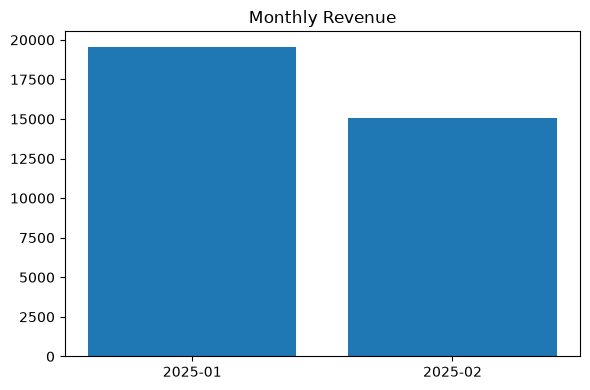

{'chart_path': 'chart_monthly_revenue.png'}

In [21]:
# Bonus tool — Make a chart
def make_chart(chart_type="monthly_revenue"):
    fig, ax = plt.subplots(figsize=(6, 4))
    if chart_type == "monthly_revenue":
        grouped = df.groupby("month")["total_price"].sum()
        ax.bar(grouped.index, grouped.values)
        ax.set_title("Monthly Revenue")
    elif chart_type == "top_products":
        grouped = df.groupby("product_name")["total_price"].sum().sort_values(ascending=False).head(8)
        ax.barh(grouped.index[::-1], grouped.values[::-1])
        ax.set_title("Top Products")
    fig.tight_layout()
    path = f"chart_{chart_type}.png"
    fig.savefig(path)
    plt.show()
    return {"chart_path": path}

# test it - this should show a chart below
make_chart("monthly_revenue")

In [22]:
# Tool Schemas & Dictionary Mapping
# Let Ollama choose and call the tools automatically.

TOOLS = {
    "get_total_revenue": get_total_revenue,
    "get_monthly_sales": get_monthly_sales,
    "get_top_products": get_top_products,
    "get_customer_stats": get_customer_stats,
    "compare_periods": compare_periods,
    "make_chart": make_chart,
}

TOOL_SCHEMAS = [
    {"type": "function", "function": {
        "name": "get_total_revenue",
        "description": "Get total revenue, order count, and average order value.",
        "parameters": {"type": "object", "properties": {}},
    }},
    {"type": "function", "function": {
        "name": "get_monthly_sales",
        "description": "Get revenue grouped by month.",
        "parameters": {"type": "object", "properties": {}},
    }},
    {"type": "function", "function": {
        "name": "get_top_products",
        "description": "Get best or worst selling products by revenue.",
        "parameters": {"type": "object", "properties": {
            "n": {"type": "integer"},
            "order": {"type": "string", "enum": ["top", "bottom"]},
        }},
    }},
    {"type": "function", "function": {
        "name": "get_customer_stats",
        "description": "Get customer count and top spending customers.",
        "parameters": {"type": "object", "properties": {}},
    }},
    {"type": "function", "function": {
        "name": "compare_periods",
        "description": "Compare revenue between two date ranges, format YYYY-MM-DD.",
        "parameters": {"type": "object", "properties": {
            "period1_start": {"type": "string"}, "period1_end": {"type": "string"},
            "period2_start": {"type": "string"}, "period2_end": {"type": "string"},
        }, "required": ["period1_start", "period1_end", "period2_start", "period2_end"]},
    }},
    {"type": "function", "function": {
        "name": "make_chart",
        "description": "Generate a chart image. chart_type: monthly_revenue or top_products.",
        "parameters": {"type": "object", "properties": {
            "chart_type": {"type": "string", "enum": ["monthly_revenue", "top_products"]},
        }},
    }},
]

print("Tools ready:", list(TOOLS.keys()))

Tools ready: ['get_total_revenue', 'get_monthly_sales', 'get_top_products', 'get_customer_stats', 'compare_periods', 'make_chart']


In [23]:
# System Prompt
SYSTEM_PROMPT = """You are an AI Business Analyst.
Never calculate numbers yourself - always call the right tool(s) to get real numbers.
If a tool returns an error, tell the user honestly instead of guessing.
If the question needs more than one tool, call them one after another.
Be concise and explain the numbers in plain business language.
"""

In [25]:
def ask_ollama(question, history=None, max_steps=5):
    history = history or []
    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history + [
        {"role": "user", "content": question}
    ]

    for step in range(max_steps):
        response = ollama.chat(model=MODEL, messages=messages, tools=TOOL_SCHEMAS)
        msg = response["message"]

        if not msg.get("tool_calls"):
            return msg["content"]  # final answer, done

        print(f"[step {step+1}] model wants to call: "
              f"{[c['function']['name'] for c in msg['tool_calls']]}")

        messages.append(msg)
        for call in msg["tool_calls"]:
            name = call["function"]["name"]
            args = call["function"].get("arguments", {}) or {}
            result = TOOLS[name](**args) if name in TOOLS else {"error": f"unknown tool {name}"}
            
            # Adjustment here to ensure pandas numbers are accepted without errors
            messages.append({"role": "tool", "name": name, "content": json.dumps(result, default=str)})

    return "Couldn't finish in time - try a simpler question."

In [26]:
answer = ask_ollama("What's our total revenue?")
print(answer)

[step 1] model wants to call: ['get_total_revenue']
Our total revenue is $34,597. This was generated from 50 orders, resulting in an average order value of $691.94.


In [ ]:
answer = ask_ollama(
    "Compare January and February revenue, and tell me which products are underperforming."
)
print(answer)

In [ ]:
def analyze_business():
    facts = {
        "revenue": get_total_revenue(),
        "monthly_sales": get_monthly_sales(),
        "top_products": get_top_products(5, "top"),
        "worst_products": get_top_products(5, "bottom"),
        "customers": get_customer_stats(),
    }

    prompt = (
        "Here are calculated business facts as JSON. Do NOT recalculate anything. "
        "Write a short report with: Key Findings, Notable Changes, Recommendations.\n\n"
        + json.dumps(facts, indent=2, default=str)
    )
    response = ollama.chat(model=MODEL, messages=[
        {"role": "system", "content": "You are a business analyst. Interpret given facts, never invent numbers."},
        {"role": "user", "content": prompt},
    ])
    return response["message"]["content"]

# Run the comprehensive report
report = analyze_business()
print(report)

## Business Performance Analysis Report

### Key Findings

Overall business performance generated a total revenue of $34,597 from 50 orders, resulting in an average order value (AOV) of $691.94.

Product performance is highly polarized. "Headphones" were the top revenue generator at $11,338, significantly outperforming other items. Conversely, "Laptop" generated the least revenue among the listed products ($2,546).

The customer base is small, comprising only 5 total customers. Revenue is heavily concentrated among the top three customers: Omar ($10,826), Sara ($7,971), and Ahmed ($7,392).

### Notable Changes

There is a notable decline in monthly sales between January 2025 ($19,560) and February 2025 ($15,037).

### Recommendations

1. **Investigate Monthly Decline:** Immediate analysis is required to understand the cause of the drop in monthly sales observed between January and February 2025.
2. **Capitalize on Best Sellers:** Given that "Headphones" are the top product, marketing e

In [ ]:
# Install gradio if not installed yet
# !pip install gradio --quiet

import gradio as gr
print("Gradio imported successfully!")

e:\Yossra_aminFiles\New folder\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gradio imported successfully!


In [ ]:
def chat_response(message, history):
    if df is None:
        return "⚠️ Please upload a CSV file first."
    # history from gr.ChatInterface is ALREADY a list of {"role":..., "content":...} dicts
    # -> no conversion needed, just pass it straight to ask_ollama
    response = ask_ollama(message, history=history)
    return response

def generate_report_ui():
    return analyze_business()

In [ ]:
def load_csv(file):
    global df
    if file is None:
        return "No file uploaded."
    try:
        new_df = pd.read_csv(file.name)
        required = {"order_date", "customer_name", "product_name", "category",
                    "quantity", "unit_price", "total_price"}
        missing = required - set(new_df.columns)
        if missing:
            return f"⚠️ Missing columns: {missing}"
        new_df["order_date"] = pd.to_datetime(new_df["order_date"])
        new_df["month"] = new_df["order_date"].dt.to_period("M").astype(str)
        df = new_df
        return f"✅ Loaded {len(df)} rows, from {df['order_date'].min().date()} to {df['order_date'].max().date()}."
    except Exception as e:
        return f"⚠️ Error loading file: {e}"

with gr.Blocks(title="AI Business Analyst") as demo:
    gr.Markdown("# 📊 AI Business Analyst")
    gr.Markdown("Ask questions about your sales data or generate an executive summary report.")

    with gr.Tab("📂 Upload Data"):
        file_in = gr.File(label="Upload Sales CSV", file_types=[".csv"])
        upload_status = gr.Markdown()
        file_in.change(load_csv, inputs=file_in, outputs=upload_status)

    with gr.Tab("💬 Chat Analyst"):
        chatbot = gr.ChatInterface(
            fn=chat_response,
            examples=[
                "What is our total revenue?",
                "Which product sold the most?",
                "Show me the monthly sales break-down"
            ]
        )

    with gr.Tab("📝 Executive Report"):
        report_btn = gr.Button("Generate Comprehensive Report", variant="primary")
        report_output = gr.Markdown()
        report_btn.click(fn=generate_report_ui, outputs=report_output)

demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


[step 1] model wants to call: ['get_total_revenue']
[step 1] model wants to call: ['get_top_products']
